# RL Demo: From Value Iteration to DQN, and Why We Still Need Policy Gradient

A progressive demo using the same 2D MuJoCo crawler throughout. Each method solves one bottleneck, then fails when we make the problem slightly more realistic.

| Demo | Algorithm | State | Actions | Result | Bottleneck / Lesson |
|------|-----------|-------|---------|--------|---------------------|
| 0 | Value Iteration | 2D discrete angles (81 states) | 4 discrete | Barely works | Needs model access, and the 2D state is not Markov |
| 1 | Tabular Q-learning | 2D discrete angles | 4 discrete | Works | Learns from experience, no model needed |
| 2 | Tabular Q-learning | 4D discrete (angles + velocities) | 4 discrete | Breaks | Curse of dimensionality |
| 3 | DQN | 4D continuous state | 4 discrete | Works | Neural network handles large/continuous state spaces |
| 3A-3B | DQN diagnostics | 4D continuous state | 4 discrete | Explain why DQN needs replay, target networks, and Double DQN | Stabilization matters |
| 4 | DQN with finer action discretization | 4D continuous state | 49-121 discrete | Breaks | Discrete-action argmax does not scale to continuous control |

**Punchline:** exact methods need a model, tabular methods do not scale, and DQN still needs discrete actions. For continuous torques, we need a policy that directly outputs actions -> policy gradient methods.

In [26]:
# Setup - run this first
!pip install -q mujoco

import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from pathlib import Path
import collections
import time

# Check if torch is available (pre-installed on Colab)
import torch
import torch.nn as nn
import torch.optim as optim

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
print('Setup complete!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Setup complete!


In [27]:
# ============================================================
# Crawler Environment
# ============================================================

CRAWLER_XML = """
<mujoco model="crawler2d">
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.005" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <geom conaffinity="1" condim="3" friction="1.5 0.5 0.1" density="1000"/>
    <joint armature="0.1" damping="0.5"/>
  </default>

  <asset>
    <texture type="2d" name="grid" builtin="checker" width="512" height="512"
             rgb1="0.7 0.9 0.7" rgb2="0.6 0.85 0.6"/>
    <material name="grid" texture="grid" texrepeat="8 8"/>
  </asset>

  <worldbody>
    <light diffuse="0.8 0.8 0.8" pos="0 -2 3" dir="0 0.5 -1"/>
    <geom name="floor" type="plane" size="50 1 0.1" material="grid"/>

    <!-- Ruler: distance markers along x-axis -->
    <geom name="origin" type="box" size="0.01 0.15 0.002" pos="0 0 0.001" rgba="0.1 0.1 0.8 0.7" contype="0" conaffinity="0"/>
    <geom name="ruler_m4" type="box" size="0.006 0.12 0.002" pos="-2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m3" type="box" size="0.003 0.08 0.001" pos="-1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_m2" type="box" size="0.006 0.12 0.002" pos="-1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m1" type="box" size="0.003 0.08 0.001" pos="-0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_1" type="box" size="0.003 0.08 0.001" pos="0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_2" type="box" size="0.006 0.12 0.002" pos="1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_3" type="box" size="0.003 0.08 0.001" pos="1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_4" type="box" size="0.006 0.12 0.002" pos="2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_5" type="box" size="0.003 0.08 0.001" pos="2.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_6" type="box" size="0.006 0.12 0.002" pos="3.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_7" type="box" size="0.003 0.08 0.001" pos="3.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_8" type="box" size="0.006 0.12 0.002" pos="4.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_9" type="box" size="0.003 0.08 0.001" pos="4.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_10" type="box" size="0.006 0.12 0.002" pos="5.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_11" type="box" size="0.003 0.08 0.001" pos="5.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_12" type="box" size="0.006 0.12 0.002" pos="6.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_13" type="box" size="0.003 0.08 0.001" pos="6.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_14" type="box" size="0.006 0.12 0.002" pos="7.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_15" type="box" size="0.003 0.08 0.001" pos="7.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_16" type="box" size="0.006 0.12 0.002" pos="8.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_17" type="box" size="0.003 0.08 0.001" pos="8.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_18" type="box" size="0.006 0.12 0.002" pos="9.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_19" type="box" size="0.003 0.08 0.001" pos="9.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_20" type="box" size="0.006 0.12 0.002" pos="10.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_21" type="box" size="0.003 0.08 0.001" pos="10.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_22" type="box" size="0.006 0.12 0.002" pos="11.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_23" type="box" size="0.003 0.08 0.001" pos="11.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_24" type="box" size="0.006 0.12 0.002" pos="12.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_25" type="box" size="0.003 0.08 0.001" pos="12.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_26" type="box" size="0.006 0.12 0.002" pos="13.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_27" type="box" size="0.003 0.08 0.001" pos="13.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_28" type="box" size="0.006 0.12 0.002" pos="14.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_29" type="box" size="0.003 0.08 0.001" pos="14.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_30" type="box" size="0.006 0.12 0.002" pos="15.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_31" type="box" size="0.003 0.08 0.001" pos="15.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_32" type="box" size="0.006 0.12 0.002" pos="16.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_33" type="box" size="0.003 0.08 0.001" pos="16.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_34" type="box" size="0.006 0.12 0.002" pos="17.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_35" type="box" size="0.003 0.08 0.001" pos="17.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_36" type="box" size="0.006 0.12 0.002" pos="18.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_37" type="box" size="0.003 0.08 0.001" pos="18.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_38" type="box" size="0.006 0.12 0.002" pos="19.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_39" type="box" size="0.003 0.08 0.001" pos="19.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_40" type="box" size="0.006 0.12 0.002" pos="20.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>

    <camera name="side" pos="0 -0.8 0.25" xyaxes="1 0 0 0 0.3 1" mode="trackcom"/>

    <body name="torso" pos="0 0 0.035">
      <joint name="root_x" type="slide" axis="1 0 0"/>
      <joint name="root_z" type="slide" axis="0 0 1"/>
      <joint name="root_rot" type="hinge" axis="0 1 0"/>

      <geom name="torso_geom" type="box" size="0.08 0.035 0.025"
            rgba="0.3 0.75 0.3 1" density="3000"/>

      <body name="arm" pos="0.08 0 0.01">
        <joint name="arm_joint" type="hinge" axis="0 1 0"
               range="-70 70" limited="true"/>
        <geom name="arm_geom" type="capsule" size="0.012"
              fromto="0 0 0 0.12 0 0" rgba="0.95 0.7 0.1 1"/>

        <body name="hand" pos="0.12 0 0">
          <joint name="hand_joint" type="hinge" axis="0 1 0"
                 range="-70 70" limited="true"/>
          <geom name="hand_geom" type="capsule" size="0.008"
                fromto="0 0 0 0.08 0 0" rgba="0.9 0.15 0.15 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="arm_motor" joint="arm_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="5"/>
    <motor name="hand_motor" joint="hand_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="3"/>
  </actuator>
</mujoco>
"""


class CrawlerEnv:
    """2D MuJoCo crawler with 2 actuated joints.
    
    State:  joint angles (and optionally velocities) - always continuous
    Action: 2D torque vector (continuous)
    Reward: forward (x) velocity
    """

    def __init__(self, include_velocity=False, max_steps=500, frame_skip=4):
        self.model = mujoco.MjModel.from_xml_string(CRAWLER_XML)
        self.data = mujoco.MjData(self.model)
        self.include_velocity = include_velocity
        self.max_steps = max_steps
        self.frame_skip = frame_skip
        self.steps = 0

        # Ranges for discretization
        self.angle_lo, self.angle_hi = np.deg2rad(-70), np.deg2rad(70)
        self.vel_lo, self.vel_hi = -8.0, 8.0

    # ---------- observation ----------
    def get_obs(self):
        """Return continuous observation."""
        arm_a, hand_a = self.data.qpos[3], self.data.qpos[4]
        if self.include_velocity:
            arm_v, hand_v = self.data.qvel[3], self.data.qvel[4]
            return np.array([arm_a, hand_a, arm_v, hand_v], dtype=np.float32)
        return np.array([arm_a, hand_a], dtype=np.float32)

    def discretize(self, obs, n_bins):
        """Convert continuous obs to a tuple of bin indices."""
        def _bin(val, lo, hi):
            val = np.clip(val, lo, hi)
            idx = int((val - lo) / (hi - lo) * n_bins)
            return min(idx, n_bins - 1)

        arm_b = _bin(obs[0], self.angle_lo, self.angle_hi)
        hand_b = _bin(obs[1], self.angle_lo, self.angle_hi)
        if len(obs) > 2:
            arm_vb = _bin(obs[2], self.vel_lo, self.vel_hi)
            hand_vb = _bin(obs[3], self.vel_lo, self.vel_hi)
            return (arm_b, hand_b, arm_vb, hand_vb)
        return (arm_b, hand_b)

    # ---------- dynamics ----------
    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[3] = np.random.uniform(-0.1, 0.1)
        self.data.qpos[4] = np.random.uniform(-0.1, 0.1)
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self.get_obs()

    def step(self, ctrl):
        """ctrl: 2-element array of torques in [-1, 1]."""
        x_before = self.data.qpos[0]
        self.data.ctrl[:] = np.clip(ctrl, -1, 1)
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        x_after = self.data.qpos[0]
        dt = self.frame_skip * self.model.opt.timestep
        reward = (x_after - x_before) / dt
        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self.get_obs(), reward, False, truncated, {'x': x_after}


# ---------- Discrete action maps ----------
# 4 coarse actions: all combinations of +/- torque on each joint
ACTIONS_4 = {
    0: np.array([1.0, 1.0]),
    1: np.array([1.0, -1.0]),
    2: np.array([-1.0, 1.0]),
    3: np.array([-1.0, -1.0]),
}

def make_fine_actions(n_bins):
    """Create a grid of n_bins^2 discrete torque pairs."""
    torques = np.linspace(-1, 1, n_bins)
    actions = {}
    idx = 0
    for a in torques:
        for b in torques:
            actions[idx] = np.array([a, b])
            idx += 1
    return actions

print('Environment defined. Let\'s see what our crawler looks like!')

Environment defined. Let's see what our crawler looks like!


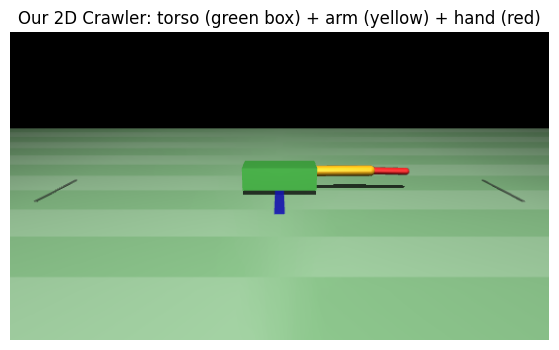

In [28]:
# ============================================================
# Visualization helpers
# ============================================================

# Collect eval results across demos for final comparison
eval_results = {}


def render_episode(env, policy_fn, max_steps=500, cam_name='side'):
    """Roll out a policy and collect rendered frames.
    
    policy_fn(obs) -> ctrl (2-element array of torques)
    Returns: (frames, distance, total_reward)
    """
    renderer = mujoco.Renderer(env.model, height=320, width=560)
    frames = []
    obs = env.reset()
    total_reward = 0
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    renderer.close()
    return frames, dist, total_reward


def eval_policy(env, policy_fn, label, max_steps=500):
    """Run a 10s rollout, render video, print distance, store result."""
    frames, dist, total_reward = render_episode(env, policy_fn, max_steps=max_steps)
    print(f'{label}: traveled {dist:.2f}m in 10s  (episode reward: {total_reward:.1f})')
    eval_results[label] = dist
    return frames, dist, total_reward


def show_video(frames, fps=30, title=None):
    """Display frames as inline video."""
    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None):
    """Plot episode rewards with a smoothed average."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color='steelblue', linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_eval_comparison(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    """Bar chart comparing distances across all evaluated policies."""
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.5 + 1)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# ============================================================
# Rolling checkpoint helpers
# ============================================================

CHECKPOINT_DIR = Path('saved_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_CHECKPOINT_PATH = CHECKPOINT_DIR / 'latest_training.pt'
LOAD_LATEST_IF_COMPATIBLE = True


def action_map_signature(action_map):
    """Compact, hashable description of a discrete action map."""
    return tuple(
        (int(k), tuple(np.asarray(v, dtype=np.float32).round(6).tolist()))
        for k, v in sorted(action_map.items())
    )


def save_latest_checkpoint(payload):
    """Overwrite the rolling latest-training checkpoint."""
    payload = dict(payload)
    payload['saved_at'] = time.strftime('%Y-%m-%d %H:%M:%S')
    torch.save(payload, LATEST_CHECKPOINT_PATH)
    print(f'Saved latest checkpoint -> {LATEST_CHECKPOINT_PATH}')


def load_latest_checkpoint(verbose=True):
    """Load the rolling latest-training checkpoint if it exists."""
    if not LATEST_CHECKPOINT_PATH.exists():
        return None
    payload = torch.load(LATEST_CHECKPOINT_PATH, map_location='cpu', weights_only=False)
    if verbose:
        print(f'Found latest checkpoint <- {LATEST_CHECKPOINT_PATH}')
        print(f"  label={payload.get('label', 'unknown')} | kind={payload.get('kind', 'unknown')}")
    return payload


def checkpoint_matches(payload, *, kind, required_meta):
    if payload is None or payload.get('kind') != kind:
        return False
    meta = payload.get('meta', {})
    return all(meta.get(k) == v for k, v in required_meta.items())


def maybe_load_latest_tabular(*, n_bins, obs_dim, action_map, label):
    """Reload the rolling checkpoint when it matches this tabular setup."""
    if not LOAD_LATEST_IF_COMPATIBLE:
        return None
    required_meta = {
        'n_bins': int(n_bins),
        'obs_dim': int(obs_dim),
        'n_actions': len(action_map),
        'action_signature': action_map_signature(action_map),
    }
    payload = load_latest_checkpoint(verbose=False)
    if not checkpoint_matches(payload, kind='tabular_q', required_meta=required_meta):
        return None
    print(f'Loaded latest checkpoint for {label}; skipping retraining.')
    return (
        np.asarray(payload['Q']),
        np.asarray(payload['visit_count']),
        list(payload['rewards']),
    )


def maybe_load_latest_dqn(*, obs_dim, action_map, hidden=64, tracked=False, double=False, label):
    """Reload the rolling checkpoint when it matches this DQN setup."""
    if not LOAD_LATEST_IF_COMPATIBLE:
        return None
    required_meta = {
        'obs_dim': int(obs_dim),
        'n_actions': len(action_map),
        'hidden': int(hidden),
        'tracked': bool(tracked),
        'double': bool(double),
        'action_signature': action_map_signature(action_map),
    }
    payload = load_latest_checkpoint(verbose=False)
    if not checkpoint_matches(payload, kind='dqn', required_meta=required_meta):
        return None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, len(action_map), hidden=hidden).to(device)
    q_net.load_state_dict(payload['state_dict'])
    q_net.eval()
    print(f'Loaded latest checkpoint for {label}; skipping retraining.')
    return q_net, list(payload['rewards']), payload.get('extras', {})


# Quick test: render the crawler at rest
env = CrawlerEnv()
env.reset()
renderer = mujoco.Renderer(env.model, height=320, width=560)
renderer.update_scene(env.data, camera='side')
frame = renderer.render()
renderer.close()

plt.figure(figsize=(8, 4))
plt.imshow(frame)
plt.axis('off')
plt.title('Our 2D Crawler: torso (green box) + arm (yellow) + hand (red)')
plt.show()

---
## Demo 0: Value Iteration -- when you **have** the dynamics model

**Setup:** Same 81-state crawler (9x9 bins of joint angles), 4 discrete actions.

Value Iteration requires **full model access** -- we must *teleport* the crawler to every state
and observe every transition before we can even start solving.

**Three things to watch:**
1. The model-building step: 324 explicit simulator queries (teleportation!)
2. VI converges instantly on 81 states -- the algorithm itself is fast
3. But the policy barely works... why?

**Spoiler:** Our 2D state (angles only) ignores velocity. The same angles can lead
to different outcomes depending on how fast the joints are moving. The Markov property
is violated, so the model is **wrong**. Even with god-mode access, garbage in = garbage out.

In [29]:
# ============================================================
# Demo 0: Value Iteration on the 2D Crawler
# ============================================================

N_BINS = 9
n_actions = len(ACTIONS_4)
env_vi = CrawlerEnv(include_velocity=False, max_steps=500)

# Bin centers for joint angles
angle_centers = np.linspace(env_vi.angle_lo, env_vi.angle_hi, N_BINS)

# ---- Step 1: Build the transition model by TELEPORTATION ----
# For each state-action pair, we SET the simulator to that state and step forward.
T = np.zeros((N_BINS, N_BINS, n_actions, 2), dtype=np.int32)  # next state
R_table = np.zeros((N_BINS, N_BINS, n_actions))               # reward

print('Step 1: Building transition model...')
print(f'  Teleporting to each of {N_BINS**2} states x {n_actions} actions = {N_BINS**2 * n_actions} simulator calls')
print()

t0 = time.time()
for i, arm_angle in enumerate(angle_centers):
    for j, hand_angle in enumerate(angle_centers):
        for a in range(n_actions):
            # TELEPORT: set the crawler to this exact configuration
            mujoco.mj_resetData(env_vi.model, env_vi.data)
            env_vi.data.qpos[3] = arm_angle
            env_vi.data.qpos[4] = hand_angle
            env_vi.data.qvel[:] = 0  # zero velocity -- this is an approximation!
            mujoco.mj_forward(env_vi.model, env_vi.data)
            env_vi.steps = 0

            obs_next, reward, _, _, _ = env_vi.step(ACTIONS_4[a])
            T[i, j, a] = env_vi.discretize(obs_next, N_BINS)
            R_table[i, j, a] = reward

build_time = time.time() - t0
print(f'  Model built in {build_time:.2f}s ({N_BINS**2 * n_actions} teleportation calls)')

# ---- Step 2: Value Iteration ----
print('\nStep 2: Running Value Iteration...')
gamma = 0.99
V = np.zeros((N_BINS, N_BINS))

t0 = time.time()
for iteration in range(500):
    V_new = np.zeros_like(V)
    for i in range(N_BINS):
        for j in range(N_BINS):
            vals = [R_table[i, j, a] + gamma * V[T[i, j, a, 0], T[i, j, a, 1]]
                    for a in range(n_actions)]
            V_new[i, j] = max(vals)
    delta = np.max(np.abs(V_new - V))
    V = V_new
    if delta < 1e-6:
        break

vi_time = time.time() - t0
print(f'  Converged in {iteration+1} iterations ({vi_time:.3f}s)')

# Extract greedy policy
pi_vi = np.zeros((N_BINS, N_BINS), dtype=np.int32)
for i in range(N_BINS):
    for j in range(N_BINS):
        vals = [R_table[i, j, a] + gamma * V[T[i, j, a, 0], T[i, j, a, 1]]
                for a in range(n_actions)]
        pi_vi[i, j] = np.argmax(vals)

print(f'  V* range: [{V.min():.1f}, {V.max():.1f}]')

# ---- Step 3: Evaluate -- roll out the VI policy ----
print('\nStep 3: Evaluating VI policy...')
rewards_vi_eval = []
for trial in range(20):
    obs = env_vi.reset()
    ep_r = 0
    while True:
        state = env_vi.discretize(obs, N_BINS)
        action = ACTIONS_4[pi_vi[state]]
        obs, r, terminated, truncated, _ = env_vi.step(action)
        ep_r += r
        if terminated or truncated:
            break
    rewards_vi_eval.append(ep_r)

# Random baseline
rewards_random = []
for trial in range(20):
    obs = env_vi.reset()
    ep_r = 0
    while True:
        action = ACTIONS_4[np.random.randint(4)]
        obs, r, terminated, truncated, _ = env_vi.step(action)
        ep_r += r
        if terminated or truncated:
            break
    rewards_random.append(ep_r)

print(f'  VI policy:     avg reward = {np.mean(rewards_vi_eval):.1f} +/- {np.std(rewards_vi_eval):.1f}')
print(f'  Random policy: avg reward = {np.mean(rewards_random):.1f} +/- {np.std(rewards_random):.1f}')

Step 1: Building transition model...
  Teleporting to each of 81 states x 4 actions = 324 simulator calls

  Model built in 0.03s (324 teleportation calls)

Step 2: Running Value Iteration...
  Converged in 500 iterations (0.053s)
  V* range: [-37.3, 0.2]

Step 3: Evaluating VI policy...
  VI policy:     avg reward = 1.6 +/- 0.1
  Random policy: avg reward = 2.4 +/- 1.8


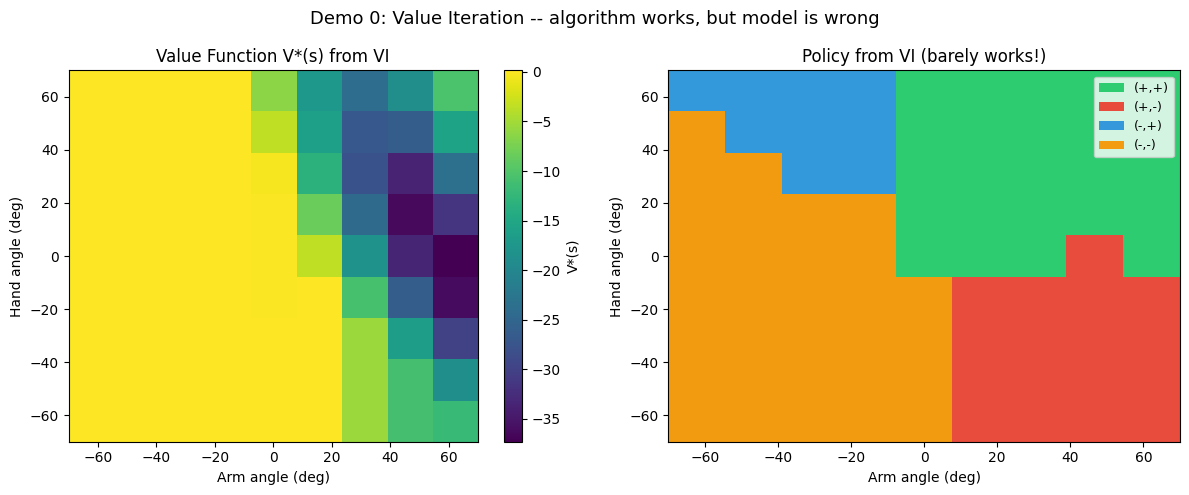

In [30]:
# Visualize VI results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arm_deg = np.rad2deg(angle_centers)
hand_deg = np.rad2deg(angle_centers)

# Value function heatmap
im = axes[0].imshow(V.T, origin='lower', cmap='viridis', aspect='auto',
                     extent=[arm_deg[0], arm_deg[-1], hand_deg[0], hand_deg[-1]])
axes[0].set_xlabel('Arm angle (deg)')
axes[0].set_ylabel('Hand angle (deg)')
axes[0].set_title('Value Function V*(s) from VI')
plt.colorbar(im, ax=axes[0], label='V*(s)')

# Policy map
action_labels = ['(+,+)', '(+,-)', '(-,+)', '(-,-)']  # (arm, hand) torque signs
action_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
color_map = {0: [0.18, 0.8, 0.44], 1: [0.91, 0.30, 0.24],
             2: [0.20, 0.60, 0.86], 3: [0.95, 0.61, 0.07]}
policy_img = np.zeros((N_BINS, N_BINS, 3))
for i in range(N_BINS):
    for j in range(N_BINS):
        policy_img[i, j] = color_map[pi_vi[i, j]]

axes[1].imshow(policy_img.transpose(1,0,2), origin='lower', aspect='auto',
               extent=[arm_deg[0], arm_deg[-1], hand_deg[0], hand_deg[-1]])
axes[1].set_xlabel('Arm angle (deg)')
axes[1].set_ylabel('Hand angle (deg)')
axes[1].set_title('Policy from VI (barely works!)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=action_colors[i], label=f'{action_labels[i]}') for i in range(4)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Demo 0: Value Iteration -- algorithm works, but model is wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
# Watch the VI policy -- it barely moves!
def vi_policy(obs):
    state = env_vi.discretize(obs, N_BINS)
    return ACTIONS_4[pi_vi[state]]

frames_vi, dist_vi, reward_vi = eval_policy(env_vi, vi_policy, 'Demo 0: Value Iteration')
show_video(frames_vi, title=f'Value Iteration Policy — {dist_vi:.2f}m in 10s (barely moves!)')

Demo 0: Value Iteration: traveled 0.03m in 10s  (episode reward: 1.3)


In [32]:
# Random baseline for comparison
def random_policy(obs):
    return ACTIONS_4[np.random.randint(len(ACTIONS_4))]

frames_random_vi, dist_random_vi, reward_random_vi = eval_policy(
    env_vi, random_policy, 'Demo 0: Random policy'
)
show_video(
    frames_random_vi,
    title=f'Random Policy — {dist_random_vi:.2f}m in 10s (comparison baseline)'
)

Demo 0: Random policy: traveled 0.05m in 10s  (episode reward: 2.6)


---
## Demo 1: Tabular Q-learning **works** on coarse discrete states

**Setup:** The crawler's state is just **(arm angle, hand angle)**, discretized into 9 bins each → **81 total states**. There are **4 discrete actions** (all ± torque combos).

The Q-table is tiny: **81 × 4 = 324 entries**. Q-learning should fill this in quickly.

In [33]:
# ============================================================
# Tabular Q-Learning
# ============================================================

def train_tabular_q(env, action_map, n_bins=9, n_episodes=2000,
                    lr=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01,
                    eps_decay=0.995, verbose=True,
                    checkpoint_label=None, checkpoint_meta=None):
    """Train tabular Q-learning. Returns Q-table and reward history."""
    n_actions = len(action_map)

    # Determine Q-table shape from observation dimensionality
    test_obs = env.reset()
    test_state = env.discretize(test_obs, n_bins)
    q_shape = (n_bins,) * len(test_state) + (n_actions,)

    Q = np.zeros(q_shape)
    visit_count = np.zeros(q_shape[:-1], dtype=np.int32)  # track visits
    epsilon = eps_start
    rewards = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        state = env.discretize(obs, n_bins)
        total_reward = 0

        while True:
            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(Q[state])

            obs, reward, terminated, truncated, _ = env.step(action_map[action])
            next_state = env.discretize(obs, n_bins)
            done = terminated or truncated

            # Q-learning update
            best_next = np.max(Q[next_state]) if not terminated else 0
            td_target = reward + gamma * best_next
            Q[state + (action,)] += lr * (td_target - Q[state + (action,)])

            visit_count[state] += 1
            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(eps_end, epsilon * eps_decay)
        rewards.append(total_reward)

        if verbose and (ep + 1) % 500 == 0:
            avg = np.mean(rewards[-100:])
            pct_visited = np.mean(visit_count > 0) * 100
            print(f'  Episode {ep+1:5d} | Avg reward: {avg:7.1f} | '
                  f'States visited: {pct_visited:.0f}% | eps: {epsilon:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')
        print(f'  Q-table shape: {Q.shape} ({Q.size} entries)')
        print(f'  States visited at least once: {np.mean(visit_count > 0)*100:.0f}%')

    if checkpoint_label is not None:
        meta = {
            'n_bins': int(n_bins),
            'obs_dim': len(test_state),
            'n_actions': n_actions,
            'action_signature': action_map_signature(action_map),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_latest_checkpoint({
            'kind': 'tabular_q',
            'label': checkpoint_label,
            'meta': meta,
            'Q': Q,
            'visit_count': visit_count,
            'rewards': np.asarray(rewards, dtype=np.float32),
        })

    return Q, visit_count, rewards

In [40]:
# ---------- Demo 1: Tabular Q-learning on 2D state ----------
N_BINS = 9

print('=== Demo 1: Tabular Q-learning with 2D state (angles only) ===')
print(f'State space: {N_BINS}x{N_BINS} = {N_BINS**2} states')
print(f'Action space: 4 discrete actions')
print(f'Q-table size: {N_BINS**2 * 4} entries\n')

env_2d = CrawlerEnv(include_velocity=False, max_steps=500)

latest = maybe_load_latest_tabular(
    n_bins=N_BINS,
    obs_dim=len(env_2d.discretize(env_2d.reset(), N_BINS)),
    action_map=ACTIONS_4,
    label='Demo 1: Tabular Q-learning (2D)',
)
# latest = None
if latest is None:
    Q_2d, visits_2d, rewards_2d = train_tabular_q(
        env_2d, ACTIONS_4, n_bins=N_BINS, n_episodes=4500,
        checkpoint_label='Demo 1: Tabular Q-learning (2D)',
        checkpoint_meta={'demo': '1', 'variant': 'tabular_2d'}
    )
else:
    Q_2d, visits_2d, rewards_2d = latest

# TODO plot time here

=== Demo 1: Tabular Q-learning with 2D state (angles only) ===
State space: 9x9 = 81 states
Action space: 4 discrete actions
Q-table size: 324 entries

  Episode   500 | Avg reward:    18.1 | States visited: 100% | eps: 0.082
  Episode  1000 | Avg reward:    31.5 | States visited: 100% | eps: 0.010
  Episode  1500 | Avg reward:    35.6 | States visited: 100% | eps: 0.010
  Episode  2000 | Avg reward:    24.9 | States visited: 100% | eps: 0.010
  Episode  2500 | Avg reward:    37.1 | States visited: 100% | eps: 0.010
  Episode  3000 | Avg reward:    35.6 | States visited: 100% | eps: 0.010
  Episode  3500 | Avg reward:    23.8 | States visited: 100% | eps: 0.010
  Episode  4000 | Avg reward:    36.9 | States visited: 100% | eps: 0.010
  Episode  4500 | Avg reward:    35.7 | States visited: 100% | eps: 0.010
  Training completed in 119.0s
  Q-table shape: (9, 9, 4) (324 entries)
  States visited at least once: 100%
Saved latest checkpoint -> saved_checkpoints/latest_training.pt


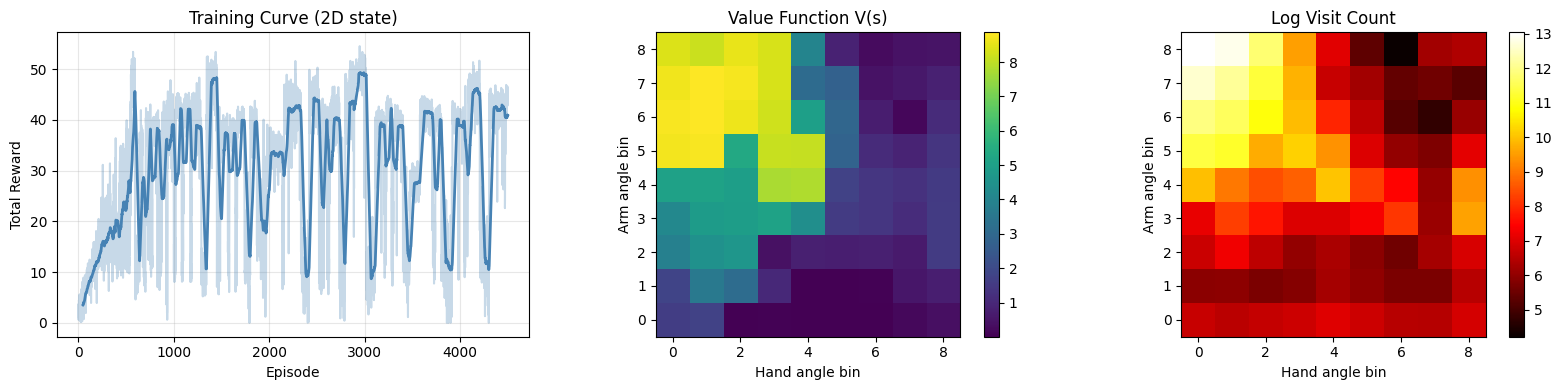

/var/folders/sz/1j1qn1v96gs82h7ywn4p48q40000gn/T/ipykernel_23858/168454257.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


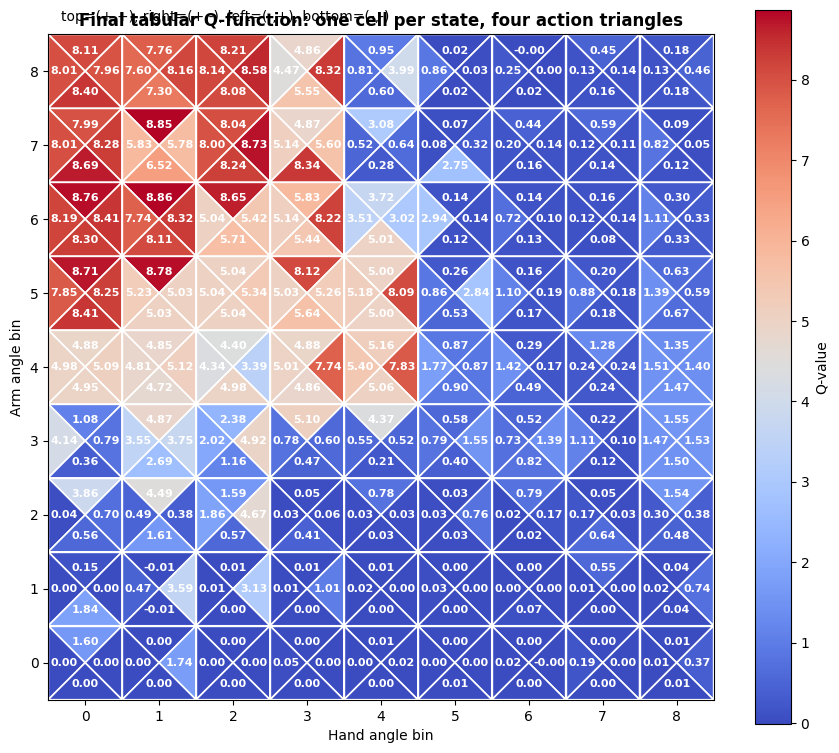

In [21]:
# Visualize the Q-table and training curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curve
plot_rewards(rewards_2d, title='Training Curve (2D state)', ax=axes[0])

# Value function: V(s) = max_a Q(s, a)
V_2d = Q_2d.max(axis=-1)
im = axes[1].imshow(V_2d, origin='lower', cmap='viridis', aspect='equal')
axes[1].set_xlabel('Hand angle bin')
axes[1].set_ylabel('Arm angle bin')
axes[1].set_title('Value Function V(s)')
plt.colorbar(im, ax=axes[1])

# Visit counts
im2 = axes[2].imshow(np.log1p(visits_2d), origin='lower', cmap='hot', aspect='equal')
axes[2].set_xlabel('Hand angle bin')
axes[2].set_ylabel('Arm angle bin')
axes[2].set_title('Log Visit Count')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Composite Q-table: each state cell is split into four action triangles
from matplotlib.patches import Polygon
from matplotlib import cm, colors

fig, ax = plt.subplots(figsize=(9, 9))
norm = colors.Normalize(vmin=Q_2d.min(), vmax=Q_2d.max())
cmap = cm.get_cmap('coolwarm')

for i in range(N_BINS):
    for j in range(N_BINS):
        x0, y0 = j, i
        xc, yc = x0 + 0.5, y0 + 0.5
        corners = {
            'bl': (x0, y0),
            'br': (x0 + 1, y0),
            'tr': (x0 + 1, y0 + 1),
            'tl': (x0, y0 + 1),
        }
        # action 0=(+,+): top, 1=(+,-): right, 2=(-,+): left, 3=(-,-): bottom
        triangles = {
            0: [corners['tl'], corners['tr'], (xc, yc)],
            1: [corners['br'], corners['tr'], (xc, yc)],
            2: [corners['bl'], corners['tl'], (xc, yc)],
            3: [corners['bl'], corners['br'], (xc, yc)],
        }
        text_pos = {
            0: (xc, y0 + 0.78),
            1: (x0 + 0.78, yc),
            2: (x0 + 0.22, yc),
            3: (xc, y0 + 0.22),
        }
        for a in range(4):
            q = Q_2d[i, j, a]
            patch = Polygon(triangles[a], closed=True, facecolor=cmap(norm(q)), edgecolor='white', linewidth=1.2)
            ax.add_patch(patch)
            tx, ty = text_pos[a]
            ax.text(tx, ty, f'{q:.2f}', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

for k in range(N_BINS + 1):
    ax.plot([0, N_BINS], [k, k], color='white', lw=1.0)
    ax.plot([k, k], [0, N_BINS], color='white', lw=1.0)

ax.set_xlim(0, N_BINS)
ax.set_ylim(0, N_BINS)
ax.set_aspect('equal')
ax.set_xticks(np.arange(N_BINS) + 0.5)
ax.set_yticks(np.arange(N_BINS) + 0.5)
ax.set_xticklabels(range(N_BINS))
ax.set_yticklabels(range(N_BINS))
ax.set_xlabel('Hand angle bin')
ax.set_ylabel('Arm angle bin')
ax.set_title('Final tabular Q-function: one cell per state, four action triangles', fontweight='bold')

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.82)
cbar.set_label('Q-value')

ax.text(0.02, 1.02, 'top=(+,+), right=(+,-), left=(-,+), bottom=(-,-)', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.show()

In [22]:
# Watch the learned policy!
def q_policy_2d(obs):
    state = env_2d.discretize(obs, N_BINS)
    action = np.argmax(Q_2d[state])
    return ACTIONS_4[action]

frames_2d, dist_2d, _ = eval_policy(env_2d, q_policy_2d, 'Demo 1: Tabular Q (2D)')
show_video(frames_2d, title=f'Tabular Q-learning: 2D state — {dist_2d:.2f}m in 10s (works!)')

Demo 1: Tabular Q (2D): traveled 0.82m in 10s  (episode reward: 41.2)


---
## Demo 2: Tabular Q-learning **breaks** with richer state

To control the crawler well, we should also know **how fast** the joints are moving — not just where they are.

Adding joint velocities makes the state **(arm_angle, hand_angle, arm_vel, hand_vel)** — a 4D space.

With 9 bins per dimension: **9^4 = 6,561 states** → Q-table has **26,244 entries**.

Sounds manageable? Let's see...

In [35]:
# ---------- Demo 2: Tabular Q-learning on 4D state ----------
print('=== Demo 2: Tabular Q-learning with 4D state (angles + velocities) ===')
print(f'State space: {N_BINS}^4 = {N_BINS**4} states')
print(f'Q-table size: {N_BINS**4 * 4} entries  (vs {N_BINS**2 * 4} before)\n')

env_4d = CrawlerEnv(include_velocity=True, max_steps=500)

latest = maybe_load_latest_tabular(
    n_bins=N_BINS,
    obs_dim=len(env_4d.discretize(env_4d.reset(), N_BINS)),
    action_map=ACTIONS_4,
    label='Demo 2: Tabular Q-learning (4D)',
)
if latest is None:
    Q_4d, visits_4d, rewards_4d = train_tabular_q(
        env_4d, ACTIONS_4, n_bins=N_BINS, n_episodes=4500,
        checkpoint_label='Demo 2: Tabular Q-learning (4D)',
        checkpoint_meta={'demo': '2', 'variant': 'tabular_4d'}
    )
else:
    Q_4d, visits_4d, rewards_4d = latest


=== Demo 2: Tabular Q-learning with 4D state (angles + velocities) ===
State space: 9^4 = 6561 states
Q-table size: 26244 entries  (vs 324 before)

  Episode   500 | Avg reward:     3.9 | States visited: 32% | eps: 0.082
  Episode  1000 | Avg reward:     6.6 | States visited: 32% | eps: 0.010
  Episode  1500 | Avg reward:    12.2 | States visited: 33% | eps: 0.010
  Episode  2000 | Avg reward:    14.4 | States visited: 33% | eps: 0.010
  Episode  2500 | Avg reward:    14.6 | States visited: 33% | eps: 0.010
  Episode  3000 | Avg reward:    13.2 | States visited: 33% | eps: 0.010
  Episode  3500 | Avg reward:    19.7 | States visited: 33% | eps: 0.010
  Episode  4000 | Avg reward:    19.4 | States visited: 33% | eps: 0.010
  Episode  4500 | Avg reward:    27.9 | States visited: 33% | eps: 0.010
  Training completed in 130.0s
  Q-table shape: (9, 9, 9, 9, 4) (26244 entries)
  States visited at least once: 33%
Saved latest checkpoint -> saved_checkpoints/latest_training.pt


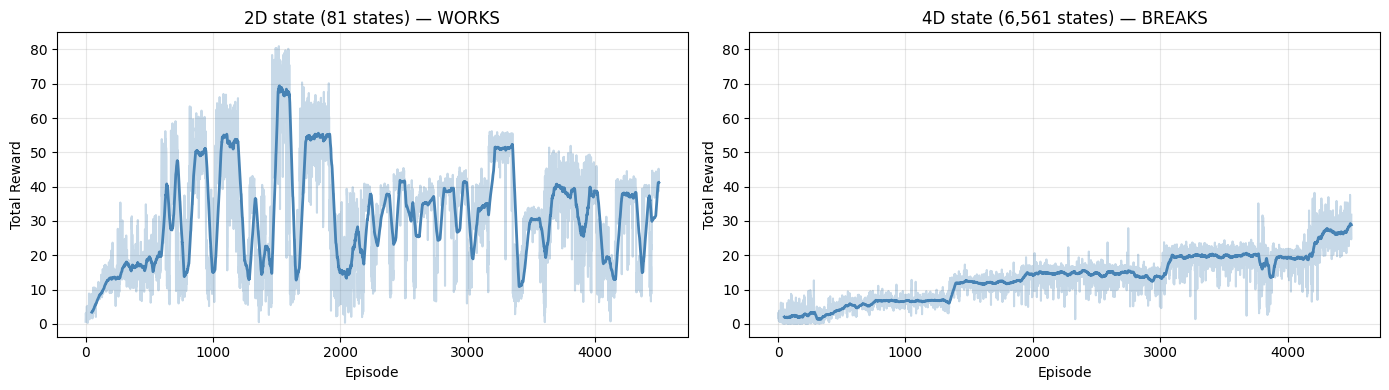


States visited at least once:
  2D state: 100% of 81 states
  4D state: 33% of 6561 states

The Q-table is mostly empty — the agent can't learn because
it rarely revisits the same (angle, angle, velocity, velocity) combination.


In [57]:
# Compare the two training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves side by side
plot_rewards(rewards_2d, title='2D state (81 states) — WORKS', ax=axes[0])
plot_rewards(rewards_4d, title='4D state (6,561 states) — BREAKS', ax=axes[1])
axes[1].set_ylim(axes[0].get_ylim())  # same y-scale for fair comparison

plt.tight_layout()
plt.show()

# Show the sparsity problem
pct_2d = np.mean(visits_2d > 0) * 100
pct_4d = np.mean(visits_4d > 0) * 100
print(f'\nStates visited at least once:')
print(f'  2D state: {pct_2d:.0f}% of {N_BINS**2} states')
print(f'  4D state: {pct_4d:.0f}% of {N_BINS**4} states')
print(f'\nThe Q-table is mostly empty — the agent can\'t learn because')
print(f'it rarely revisits the same (angle, angle, velocity, velocity) combination.')

In [37]:
# todo visualize the q table before and now

In [58]:
# Watch the 4D policy (should be visibly worse)
def q_policy_4d(obs):
    state = env_4d.discretize(obs, N_BINS)
    action = np.argmax(Q_4d[state])
    return ACTIONS_4[action]

frames_4d, dist_4d, _ = eval_policy(env_4d, q_policy_4d, 'Demo 2: Tabular Q (4D)')
show_video(frames_4d, title=f'Tabular Q-learning: 4D state — {dist_4d:.2f}m in 10s (breaks!)')

Demo 2: Tabular Q (4D): traveled 0.64m in 10s  (episode reward: 31.8)


### Why did it break?

**Curse of dimensionality.** Going from 2D → 4D state increased the table from 324 to 26,244 entries. Most states are never visited, so the Q-values there are meaningless.

And this is just 4 dimensions! A humanoid has ~60D state space. With 9 bins per dimension: **9^60 ≈ 10^57 states**. No table can hold that.

**Solution:** Instead of a table, use a **neural network** to approximate Q(s, a). Nearby states get similar Q-values — the network *generalizes*.

---
## Demo 3: DQN **fixes** the continuous state problem

Same 4D state (angles + velocities), same 4 discrete actions. But instead of a table, we use a small neural network:

```
obs (4D) → [64] → [64] → Q-values (4)
```

What that means in practice:
- **`obs (4D)`** = the input state vector: `[arm angle, hand angle, arm angular velocity, hand angular velocity]`
- **first `[64]`** = a fully connected hidden layer with 64 neurons
- **second `[64]`** = another fully connected hidden layer with 64 neurons
- **`Q-values (4)`** = the output layer: one predicted value for each of the 4 discrete actions

In code, this is:

```python
nn.Linear(4, 64), nn.ReLU(),
nn.Linear(64, 64), nn.ReLU(),
nn.Linear(64, 4)
```

So this is a **small multilayer perceptron (MLP)**. It does **not** directly output torques. It outputs four scores:

$$Q_\theta(s) = [Q_\theta(s,a_1), Q_\theta(s,a_2), Q_\theta(s,a_3), Q_\theta(s,a_4)]$$

Then DQN picks the action with the largest score:

$$a^*(s) = \arg\max_a Q_\theta(s,a)$$

Why 64? Nothing magical here: 64 hidden units is just a small, fast network that is expressive enough for this toy crawler demo.

The network generalizes across similar states — no need to visit every state individually.

In [41]:
# ============================================================
# DQN Agent
# ============================================================

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        idxs = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idxs]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


def train_dqn(env, action_map, n_episodes=400, batch_size=64, gamma=0.99,
              lr=1e-3, eps_start=1.0, eps_end=0.01, eps_decay=0.995,
              target_update=100, buffer_size=20000, verbose=True,
              checkpoint_label=None, checkpoint_meta=None):
    """Train DQN. Returns the trained network and reward history."""
    n_actions = len(action_map)
    obs_dim = len(env.reset())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    buffer = ReplayBuffer(buffer_size)
    epsilon = eps_start
    rewards = []
    total_steps = 0

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        total_reward = 0

        while True:
            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
                    action = q_vals.argmax(dim=1).item()

            next_obs, reward, terminated, truncated, _ = env.step(action_map[action])
            done = terminated or truncated
            buffer.push(obs, action, reward, next_obs, float(terminated))

            obs = next_obs
            total_reward += reward
            total_steps += 1

            # Training step
            if len(buffer) >= batch_size:
                s, a, r, ns, d = buffer.sample(batch_size)
                s_t = torch.FloatTensor(s).to(device)
                a_t = torch.LongTensor(a).to(device)
                r_t = torch.FloatTensor(r).to(device)
                ns_t = torch.FloatTensor(ns).to(device)
                d_t = torch.FloatTensor(d).to(device)

                q_values = q_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(ns_t).max(dim=1)[0]
                    target = r_t + gamma * next_q * (1 - d_t)

                loss = nn.functional.mse_loss(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Target network update
            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

            if done:
                break

        epsilon = max(eps_end, epsilon * eps_decay)
        rewards.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards[-50:])
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | eps: {epsilon:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': obs_dim,
            'n_actions': n_actions,
            'hidden': 64,
            'tracked': False,
            'double': False,
            'action_signature': action_map_signature(action_map),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        state_dict_cpu = {k: v.detach().cpu() for k, v in q_net.state_dict().items()}
        save_latest_checkpoint({
            'kind': 'dqn',
            'label': checkpoint_label,
            'meta': meta,
            'state_dict': state_dict_cpu,
            'rewards': np.asarray(rewards, dtype=np.float32),
            'extras': {},
        })

    return q_net, rewards

In [42]:
# ---------- Demo 3: DQN on 4D state, 4 discrete actions ----------
print('=== Demo 3: DQN with 4D continuous state, 4 discrete actions ===')
print(f'State: 4D continuous (arm angle, hand angle, arm vel, hand vel)')
print(f'Actions: 4 discrete (same as before)')
print(f'Q-function: neural network (4 → 64 → 64 → 4)\n')

env_dqn = CrawlerEnv(include_velocity=True, max_steps=500)

latest = maybe_load_latest_dqn(
    obs_dim=len(env_dqn.reset()),
    action_map=ACTIONS_4,
    hidden=64,
    tracked=False,
    double=False,
    label='Demo 3: DQN (4 actions)',
)
if latest is None:
    q_net_4, rewards_dqn_4 = train_dqn(
        env_dqn, ACTIONS_4, n_episodes=4500,
        checkpoint_label='Demo 3: DQN (4 actions)',
        checkpoint_meta={'demo': '3', 'variant': 'dqn_4_actions'}
    )
else:
    q_net_4, rewards_dqn_4, _ = latest

# TODO need to train the same number of episodes as the tabular Q, to be fair.

=== Demo 3: DQN with 4D continuous state, 4 discrete actions ===
State: 4D continuous (arm angle, hand angle, arm vel, hand vel)
Actions: 4 discrete (same as before)
Q-function: neural network (4 → 64 → 64 → 4)

  Episode  100 | Avg reward:     4.6 | eps: 0.606
  Episode  200 | Avg reward:    13.1 | eps: 0.367
  Episode  300 | Avg reward:    22.6 | eps: 0.222
  Episode  400 | Avg reward:    30.8 | eps: 0.135
  Episode  500 | Avg reward:    33.1 | eps: 0.082
  Episode  600 | Avg reward:    34.9 | eps: 0.049
  Episode  700 | Avg reward:    41.0 | eps: 0.030
  Episode  800 | Avg reward:    35.7 | eps: 0.018
  Episode  900 | Avg reward:    45.5 | eps: 0.011
  Episode 1000 | Avg reward:    43.4 | eps: 0.010
  Episode 1100 | Avg reward:    43.2 | eps: 0.010
  Episode 1200 | Avg reward:    37.1 | eps: 0.010
  Episode 1300 | Avg reward:    40.0 | eps: 0.010
  Episode 1400 | Avg reward:    45.6 | eps: 0.010
  Episode 1500 | Avg reward:    45.7 | eps: 0.010
  Episode 1600 | Avg reward:    44.5 |

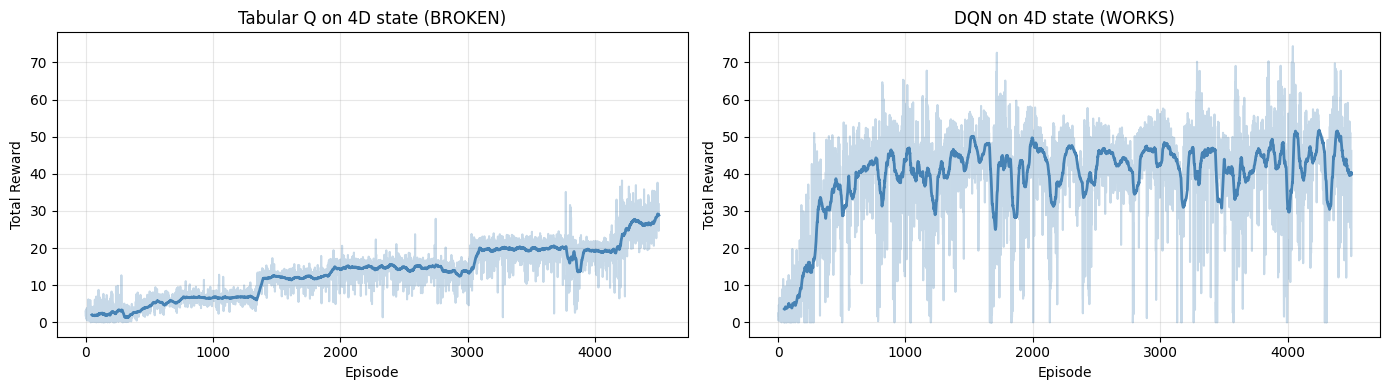

In [55]:
# Compare: tabular 4D (broken) vs DQN 4D (works)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_rewards(rewards_4d, title='Tabular Q on 4D state (BROKEN)', ax=axes[0])
plot_rewards(rewards_dqn_4, title='DQN on 4D state (WORKS)', ax=axes[1])

# Use same y-scale
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [56]:
# Watch the DQN policy
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def dqn_policy_4(obs):
    with torch.no_grad():
        q_vals = q_net_4(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return ACTIONS_4[action]

frames_dqn, dist_dqn, _ = eval_policy(env_dqn, dqn_policy_4, 'Demo 3: DQN (4 actions)')
show_video(frames_dqn, title=f'DQN: 4D state, 4 actions — {dist_dqn:.2f}m in 10s (works!)')

Demo 3: DQN (4 actions): traveled 0.59m in 10s  (episode reward: 29.7)


---
## Demo 3A: The Deadly Triad — why DQN needs its tricks

DQN works because of two key stabilization tricks:
1. **Replay buffer** — decorrelates samples (breaks the sequential correlation of on-policy data)
2. **Target network** — stabilizes the bootstrap target (prevents chasing a moving target)

Without these, the combination of **function approximation + bootstrapping + off-policy learning** (the "deadly triad") makes training diverge.

Let's **ablate** each trick and see what happens.

In [59]:
# ---------- Demo 3A: Ablation study ----------
print('=== Demo 3A: What happens without DQN\'s stabilization tricks? ===')
print('We use lr=3e-3 (3x default) to stress-test stability.\n')
print('Only the most recent training run is checkpointed, so this comparison still retrains missing variants after a crash.\n')

env_triad = CrawlerEnv(include_velocity=True, max_steps=500)

# Variant 1: No target network (target_update=1 means target = online net every step)
print('--- Variant 1: No target network (target updates every step) ---')
_, rewards_no_target = train_dqn(
    env_triad, ACTIONS_4, n_episodes=400,
    target_update=1, lr=3e-3,
    checkpoint_label='Demo 3A: No target network',
    checkpoint_meta={'demo': '3A', 'variant': 'no_target'}
)

# Variant 2: Tiny replay buffer (effectively no replay — always trains on recent data)
print('\n--- Variant 2: No replay buffer (buffer_size=64, same as batch) ---')
_, rewards_no_replay = train_dqn(
    env_triad, ACTIONS_4, n_episodes=400,
    buffer_size=64, lr=3e-3,
    checkpoint_label='Demo 3A: No replay buffer',
    checkpoint_meta={'demo': '3A', 'variant': 'no_replay'}
)

print('\nDone! Compare against full DQN (rewards_dqn_4) from Demo 3.')

=== Demo 3A: What happens without DQN's stabilization tricks? ===
We use lr=3e-3 (3x default) to stress-test stability.

Only the most recent training run is checkpointed, so this comparison still retrains missing variants after a crash.

--- Variant 1: No target network (target updates every step) ---


KeyboardInterrupt: 

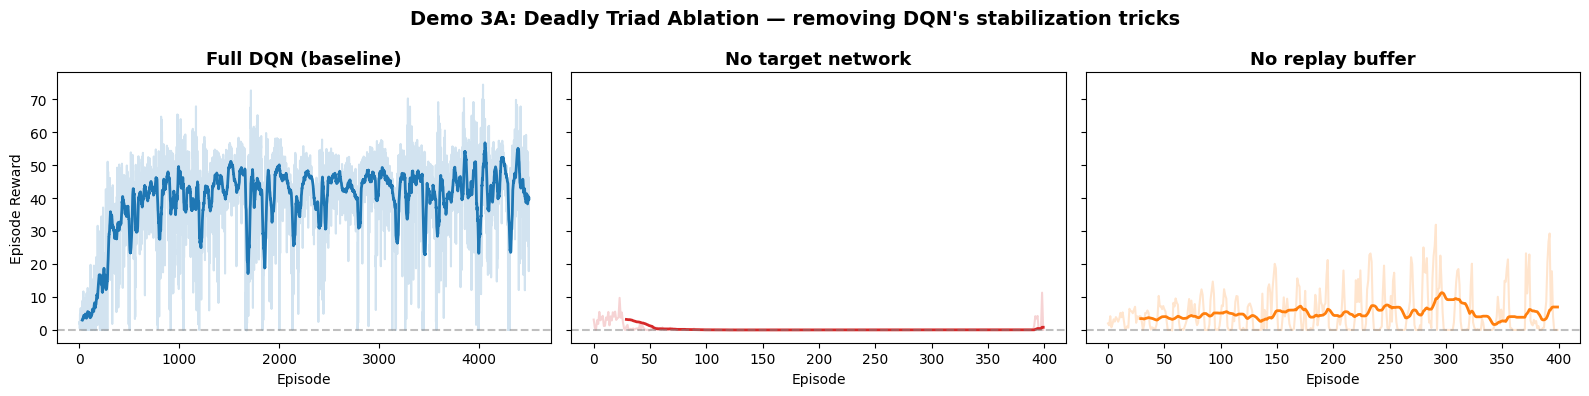

Full DQN (baseline)      : last-50 avg = 40.2
No target network        : last-50 avg = 0.5
No replay buffer         : last-50 avg = 5.9


In [46]:
# Plot ablation results
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
window = 30

data = [
    ('Full DQN (baseline)', rewards_dqn_4, 'tab:blue'),
    ('No target network', rewards_no_target, 'tab:red'),
    ('No replay buffer', rewards_no_replay, 'tab:orange'),
]

for ax, (title, rewards, color) in zip(axes, data):
    ax.plot(rewards, alpha=0.2, color=color)
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(rewards)), smoothed, color=color, lw=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.axhline(y=0, color='gray', ls='--', alpha=0.5)

axes[0].set_ylabel('Episode Reward')
fig.suptitle('Demo 3A: Deadly Triad Ablation — removing DQN\'s stabilization tricks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
for title, rewards, _ in data:
    last50 = np.mean(rewards[-50:])
    print(f'{title:25s}: last-50 avg = {last50:.1f}')

---
## Demo 3B: Overestimation Bias and Double DQN

Standard DQN uses the **same network** to both select and evaluate actions in the target:

$$\text{target} = r + \gamma \max_a Q_{\text{target}}(s', a)$$

The `max` operator systematically **overestimates** Q-values — noise in the estimates gets amplified because we always pick the noisiest (highest) value. Over time, this inflates Q-values far above their true values.

**Double DQN** (van Hasselt et al., 2016) fixes this by **decoupling** selection from evaluation:
- **Online network** selects the best action: $a^* = \arg\max_a Q_{\text{online}}(s', a)$
- **Target network** evaluates it: $Q_{\text{target}}(s', a^*)$

Let's see how Q-values behave with and without this fix.

In [47]:
def train_dqn_tracked(env, action_map, n_episodes=400, batch_size=64, gamma=0.99,
                     lr=1e-3, eps_start=1.0, eps_end=0.01, eps_decay=0.995,
                     target_update=100, buffer_size=20000, double=False, verbose=True,
                     checkpoint_label=None, checkpoint_meta=None):
    """Train DQN with Q-value tracking. If double=True, uses Double DQN."""
    n_actions = len(action_map)
    obs_dim = len(env.reset())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    buffer = ReplayBuffer(buffer_size)
    epsilon = eps_start
    rewards = []
    avg_q_values = []  # track overestimation
    total_steps = 0

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        total_reward = 0
        ep_q_vals = []

        while True:
            if np.random.random() < epsilon:
                action = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
                    ep_q_vals.append(q_vals.max().item())
                    action = q_vals.argmax(dim=1).item()

            next_obs, reward, terminated, truncated, _ = env.step(action_map[action])
            done = terminated or truncated
            buffer.push(obs, action, reward, next_obs, float(terminated))

            obs = next_obs
            total_reward += reward
            total_steps += 1

            if len(buffer) >= batch_size:
                s, a, r, ns, d = buffer.sample(batch_size)
                s_t = torch.FloatTensor(s).to(device)
                a_t = torch.LongTensor(a).to(device)
                r_t = torch.FloatTensor(r).to(device)
                ns_t = torch.FloatTensor(ns).to(device)
                d_t = torch.FloatTensor(d).to(device)

                q_values = q_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    if double:
                        # Double DQN: online net selects, target net evaluates
                        best_actions = q_net(ns_t).argmax(dim=1, keepdim=True)
                        next_q = target_net(ns_t).gather(1, best_actions).squeeze(1)
                    else:
                        # Standard DQN: target net does both
                        next_q = target_net(ns_t).max(dim=1)[0]
                    target = r_t + gamma * next_q * (1 - d_t)

                loss = nn.functional.mse_loss(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

            if done:
                break

        epsilon = max(eps_end, epsilon * eps_decay)
        rewards.append(total_reward)
        avg_q_values.append(np.mean(ep_q_vals) if ep_q_vals else 0.0)

        if verbose and (ep + 1) % 100 == 0:
            avg_r = np.mean(rewards[-50:])
            avg_q = np.mean(avg_q_values[-50:])
            label = 'Double DQN' if double else 'Standard DQN'
            print(f'  [{label}] Ep {ep+1:4d} | Avg reward: {avg_r:7.1f} | Avg Q: {avg_q:6.1f} | eps: {epsilon:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': obs_dim,
            'n_actions': n_actions,
            'hidden': 64,
            'tracked': True,
            'double': bool(double),
            'action_signature': action_map_signature(action_map),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        state_dict_cpu = {k: v.detach().cpu() for k, v in q_net.state_dict().items()}
        save_latest_checkpoint({
            'kind': 'dqn',
            'label': checkpoint_label,
            'meta': meta,
            'state_dict': state_dict_cpu,
            'rewards': np.asarray(rewards, dtype=np.float32),
            'extras': {
                'avg_q_values': np.asarray(avg_q_values, dtype=np.float32),
            },
        })

    return q_net, rewards, avg_q_values

In [48]:
# ---------- Demo 3B: Standard DQN vs Double DQN ----------
print('=== Demo 3B: Overestimation bias — Standard DQN vs Double DQN ===')
print('Both use lr=3e-3, target_update=200 to amplify overestimation.')
print('We run longer here because 400 episodes was too short to show a clear separation.\n')

env_double = CrawlerEnv(include_velocity=True, max_steps=500)

print('--- Standard DQN ---')
_, rewards_standard, qvals_standard = train_dqn_tracked(
    env_double, ACTIONS_4, n_episodes=800,
    lr=3e-3, target_update=200, double=False,
    checkpoint_label='Demo 3B: Standard DQN',
    checkpoint_meta={'demo': '3B', 'variant': 'standard'}
)

print('\n--- Double DQN ---')
_, rewards_double, qvals_double = train_dqn_tracked(
    env_double, ACTIONS_4, n_episodes=800,
    lr=3e-3, target_update=200, double=True,
    checkpoint_label='Demo 3B: Double DQN',
    checkpoint_meta={'demo': '3B', 'variant': 'double'}
)

=== Demo 3B: Overestimation bias — Standard DQN vs Double DQN ===
Both use lr=3e-3, target_update=200 to amplify overestimation.
We run longer here because 400 episodes was too short to show a clear separation.

--- Standard DQN ---
  [Standard DQN] Ep  100 | Avg reward:     7.2 | Avg Q:   14.1 | eps: 0.606
  [Standard DQN] Ep  200 | Avg reward:    13.9 | Avg Q:   14.1 | eps: 0.367
  [Standard DQN] Ep  300 | Avg reward:    18.3 | Avg Q:   11.8 | eps: 0.222
  [Standard DQN] Ep  400 | Avg reward:    35.5 | Avg Q:   10.4 | eps: 0.135
  [Standard DQN] Ep  500 | Avg reward:    35.9 | Avg Q:    9.7 | eps: 0.082
  [Standard DQN] Ep  600 | Avg reward:    20.9 | Avg Q:   11.6 | eps: 0.049
  [Standard DQN] Ep  700 | Avg reward:    35.8 | Avg Q:   12.3 | eps: 0.030
  [Standard DQN] Ep  800 | Avg reward:    35.9 | Avg Q:   12.3 | eps: 0.018
  Training completed in 178.7s
Saved latest checkpoint -> saved_checkpoints/latest_training.pt

--- Double DQN ---
  [Double DQN] Ep  100 | Avg reward:     5.1

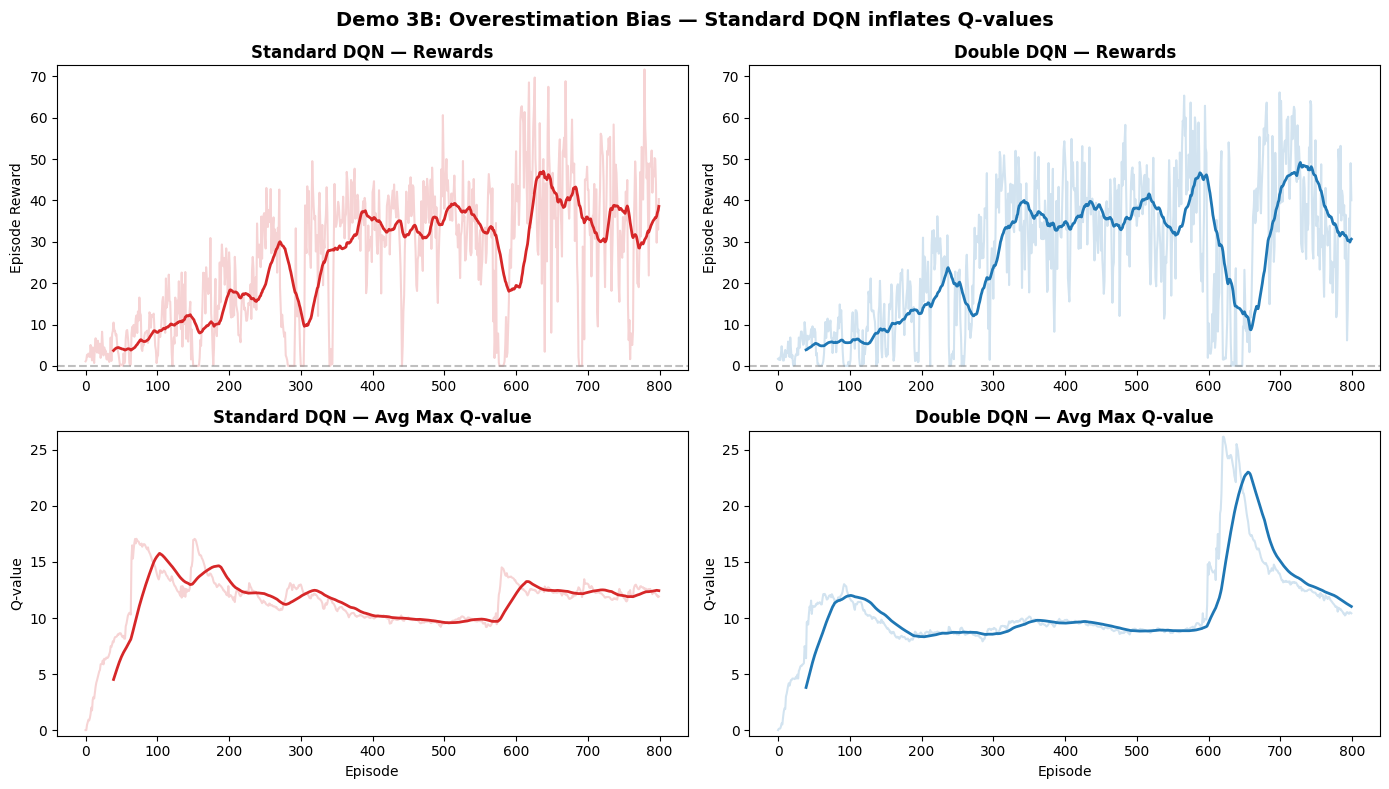

Standard DQN — final avg Q: 12.3, peak avg Q: 17.1, final avg reward: 35.9
Double DQN   — final avg Q: 11.2, peak avg Q: 26.2, final avg reward: 31.1


In [49]:
# Plot: 2x2 — rewards (top) and Q-values (bottom)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='row')
window = 40

reward_series = [np.asarray(rewards_standard), np.asarray(rewards_double)]
q_series = [np.asarray(qvals_standard), np.asarray(qvals_double)]
reward_min = min(np.min(x) for x in reward_series)
reward_max = max(np.max(x) for x in reward_series)
q_min = min(np.min(x) for x in q_series)
q_max = max(np.max(x) for x in q_series)

for col, (label, rewards, qvals, color) in enumerate([
    ('Standard DQN', rewards_standard, qvals_standard, 'tab:red'),
    ('Double DQN', rewards_double, qvals_double, 'tab:blue'),
]):
    # Top row: rewards
    ax = axes[0, col]
    ax.plot(rewards, alpha=0.2, color=color)
    sm = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(rewards)), sm, color=color, lw=2)
    ax.set_title(f'{label} — Rewards', fontsize=12, fontweight='bold')
    ax.set_ylabel('Episode Reward')
    ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
    ax.set_ylim(reward_min - 1, reward_max + 1)

    # Bottom row: Q-values
    ax = axes[1, col]
    ax.plot(qvals, alpha=0.2, color=color)
    sm_q = np.convolve(qvals, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(qvals)), sm_q, color=color, lw=2)
    ax.set_title(f'{label} — Avg Max Q-value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Q-value')
    ax.set_xlabel('Episode')
    ax.set_ylim(q_min - 0.5, q_max + 0.5)

fig.suptitle('Demo 3B: Overestimation Bias — Standard DQN inflates Q-values',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Standard DQN — final avg Q: {np.mean(qvals_standard[-50:]):.1f}, '
      f'peak avg Q: {np.max(qvals_standard):.1f}, '
      f'final avg reward: {np.mean(rewards_standard[-50:]):.1f}')
print(f'Double DQN   — final avg Q: {np.mean(qvals_double[-50:]):.1f}, '
      f'peak avg Q: {np.max(qvals_double):.1f}, '
      f'final avg reward: {np.mean(rewards_double[-50:]):.1f}')

### Takeaway: The Deadly Triad and its Solutions

| Problem | Cause | Solution |
|---------|-------|----------|
| Training divergence | Correlated sequential samples | **Replay buffer** — sample uniformly from past experience |
| Training divergence | Bootstrapping from a moving target | **Target network** — freeze target for N steps |
| Q-value overestimation | `max` operator amplifies noise | **Double DQN** — decouple action selection from evaluation |

These three tricks turn unstable Q-learning into the stable **DQN** algorithm that conquered Atari (Mnih et al., 2015).

**But DQN still requires discrete actions.** What if we need continuous control? → Demo 4

---
## Demo 4: DQN **breaks** with continuous actions

Our 4 discrete actions (all combos of ±1 torque) are crude — real motors apply **continuous torques**.

DQN needs `argmax_a Q(s, a)` — easy when there are 4 actions, but **impossible** when actions are continuous (infinite choices).

Workaround: discretize torques into a grid. Let's try:
- **Coarse:** 3 torque levels per joint → 9 actions
- **Fine:** 7 torque levels per joint → 49 actions
- **Very fine:** 11 levels → 121 actions

In [50]:
# ---------- Demo 4: DQN struggles with discretized continuous actions ----------

results = {}

for n_torque_bins, n_eps in [(3, 400), (7, 600), (11, 800)]:
    action_map = make_fine_actions(n_torque_bins)
    n_act = len(action_map)
    print(f'\n=== DQN with {n_torque_bins} torque levels → {n_act} actions ===')

    env_cont = CrawlerEnv(include_velocity=True, max_steps=500)

    latest = maybe_load_latest_dqn(
        obs_dim=len(env_cont.reset()),
        action_map=action_map,
        hidden=64,
        tracked=False,
        double=False,
        label=f'Demo 4: DQN ({n_act} actions)',
    )
    if latest is None:
        q_net, rews = train_dqn(
            env_cont, action_map, n_episodes=n_eps,
            eps_decay=0.997, lr=5e-4,
            checkpoint_label=f'Demo 4: DQN ({n_act} actions)',
            checkpoint_meta={'demo': '4', 'variant': f'{n_torque_bins}_bins'}
        )
    else:
        q_net, rews, _ = latest
    results[n_torque_bins] = (q_net, rews, action_map)


=== DQN with 3 torque levels → 9 actions ===
  Episode  100 | Avg reward:     4.7 | eps: 0.740
  Episode  200 | Avg reward:     2.7 | eps: 0.548
  Episode  300 | Avg reward:     3.3 | eps: 0.406
  Episode  400 | Avg reward:    11.9 | eps: 0.301
  Training completed in 88.2s
Saved latest checkpoint -> saved_checkpoints/latest_training.pt

=== DQN with 7 torque levels → 49 actions ===
  Episode  100 | Avg reward:     1.0 | eps: 0.740
  Episode  200 | Avg reward:     1.7 | eps: 0.548
  Episode  300 | Avg reward:     5.5 | eps: 0.406
  Episode  400 | Avg reward:     9.9 | eps: 0.301
  Episode  500 | Avg reward:    14.9 | eps: 0.223
  Episode  600 | Avg reward:    21.0 | eps: 0.165
  Training completed in 139.7s
Saved latest checkpoint -> saved_checkpoints/latest_training.pt

=== DQN with 11 torque levels → 121 actions ===
  Episode  100 | Avg reward:     4.1 | eps: 0.740
  Episode  200 | Avg reward:     4.7 | eps: 0.548
  Episode  300 | Avg reward:     3.8 | eps: 0.406
  Episode  400 | Av

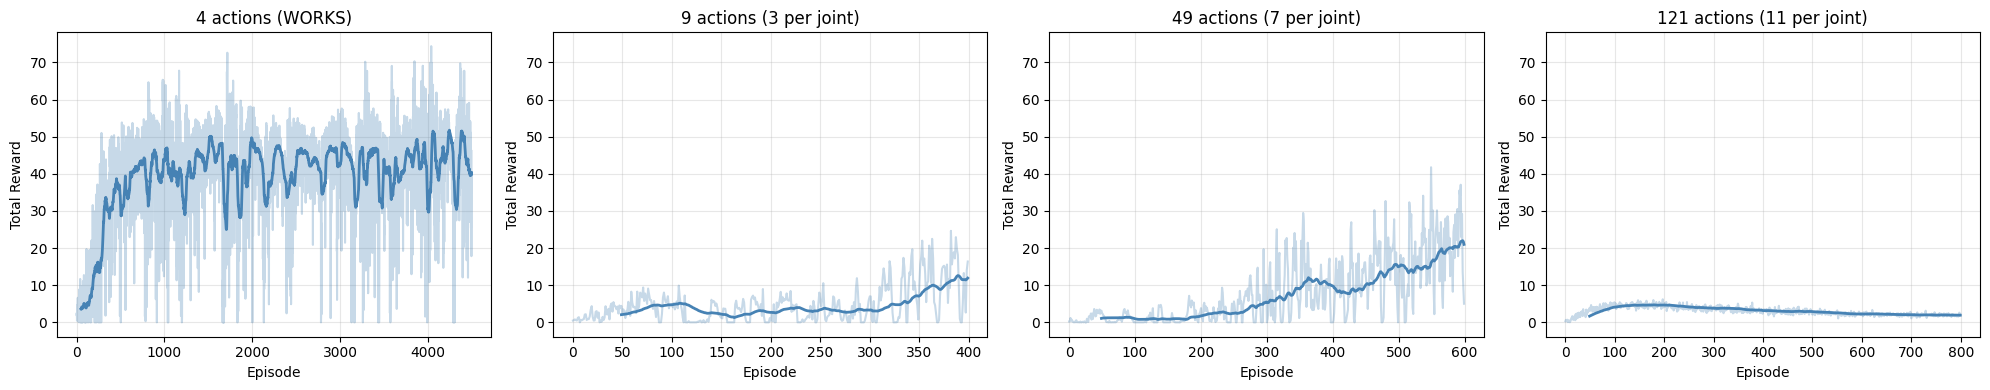


As we increase action resolution, DQN struggles more:
  4 actions:   avg last-50 reward = 40.2
    9 actions: avg last-50 reward = 11.9
   49 actions: avg last-50 reward = 21.0
  121 actions: avg last-50 reward = 1.9


In [51]:
# Compare all DQN results
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Reference: DQN with 4 actions (works)
plot_rewards(rewards_dqn_4, title='4 actions (WORKS)', ax=axes[0])

for i, (n_bins, (_, rews, _)) in enumerate(results.items()):
    n_act = n_bins ** 2
    plot_rewards(rews, title=f'{n_act} actions ({n_bins} per joint)', ax=axes[i+1])

# Same y-scale across all plots
all_ylims = [ax.get_ylim() for ax in axes]
ymin = min(y[0] for y in all_ylims)
ymax = max(y[1] for y in all_ylims)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

print('\nAs we increase action resolution, DQN struggles more:')
print(f'  4 actions:   avg last-50 reward = {np.mean(rewards_dqn_4[-50:]):.1f}')
for n_bins, (_, rews, _) in results.items():
    print(f'  {n_bins**2:3d} actions: avg last-50 reward = {np.mean(rews[-50:]):.1f}')

In [52]:
# Animate the worst case (most actions) to show the jerky/failed behavior
worst_bins = max(results.keys())
worst_net, _, worst_actions = results[worst_bins]

env_show = CrawlerEnv(include_velocity=True, max_steps=500)

def dqn_policy_fine(obs):
    with torch.no_grad():
        q_vals = worst_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return worst_actions[action]

frames_fine, dist_fine, _ = eval_policy(
    env_show, dqn_policy_fine, f'Demo 4: DQN ({worst_bins**2} actions)')
show_video(frames_fine, title=f'DQN with {worst_bins**2} actions — {dist_fine:.2f}m in 10s (breaks!)')

Demo 4: DQN (121 actions): traveled 0.03m in 10s  (episode reward: 1.5)


In [53]:
# Save reusable policies for the policy-gradient notebook comparison
save_path = Path('saved_policies')
save_path.mkdir(exist_ok=True)

dqn_checkpoint = {
    'q_net_state_dict': q_net_4.state_dict(),
    'obs_dim': 4,
    'n_actions': 4,
    'hidden': 64,
    'action_map': {int(k): v.tolist() for k, v in ACTIONS_4.items()},
}
torch.save(dqn_checkpoint, save_path / 'dqn_crawler_4act.pt')
print(f'Saved DQN policy to {save_path / "dqn_crawler_4act.pt"}')
print(f'  obs_dim={dqn_checkpoint["obs_dim"]}, n_actions={dqn_checkpoint["n_actions"]}, hidden={dqn_checkpoint["hidden"]}')

tabular_checkpoint = {
    'Q': Q_2d,
    'n_bins': N_BINS,
    'include_velocity': False,
    'angle_lo': float(env_2d.angle_lo),
    'angle_hi': float(env_2d.angle_hi),
    'action_map': {int(k): v.tolist() for k, v in ACTIONS_4.items()},
}
torch.save(tabular_checkpoint, save_path / 'tabular_q_2d.pt')
print(f'Saved tabular Q policy to {save_path / "tabular_q_2d.pt"}')
print(f'  Q shape={tabular_checkpoint["Q"].shape}, n_bins={tabular_checkpoint["n_bins"]}')

Saved DQN policy to saved_policies/dqn_crawler_4act.pt
  obs_dim=4, n_actions=4, hidden=64
Saved tabular Q policy to saved_policies/tabular_q_2d.pt
  Q shape=(9, 9, 4), n_bins=9


### Why did DQN break?

DQN needs to evaluate **every possible action** to pick the best one (argmax). When we discretize continuous torques:

- **Too few bins (coarse):** The controller can't produce smooth motion — like driving a car where the steering wheel only has 3 positions.
- **Too many bins (fine):** The action space explodes. The network struggles to figure out that torque=0.71 is almost as good as torque=0.73.

For a real robot with 20 joints, even 3 torque levels per joint gives **3^20 ≈ 3.5 billion** discrete actions. Impossible.

---

### What we need

Instead of asking *"which of these N discrete actions is best?"*, we need a method that **directly outputs continuous values**:

$$\pi_\theta(s) \rightarrow a \in \mathbb{R}^n$$

A **policy network** that takes the state and directly outputs torques. No argmax, no enumeration.

How do we train it? **Policy gradient methods** — the topic of the next lecture.

The idea: instead of learning Q-values and deriving a policy, directly optimize the policy parameters by gradient ascent on expected reward.

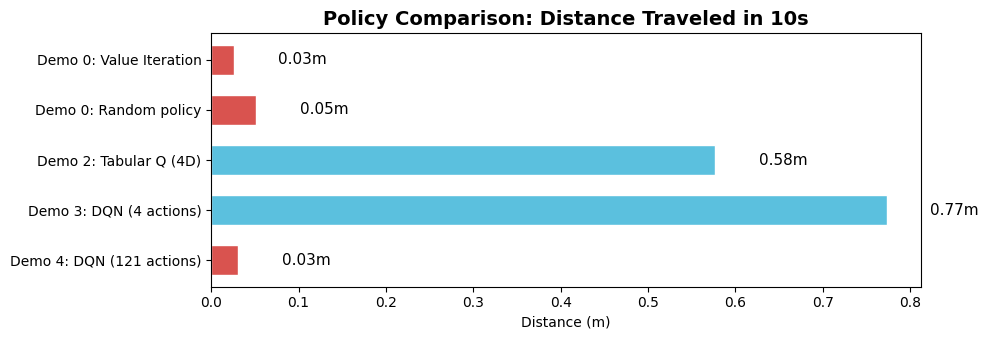

In [54]:
# ============================================================
# Final comparison: how far does each policy get in 10 seconds?
# ============================================================
plot_eval_comparison(eval_results)

---
## Summary

| Method | State | Actions | Result | Distance (10s) | Bottleneck |
|--------|-------|---------|--------|----------------|------------|
| **Value Iteration** | 2D (81 states) | 4 discrete | Barely works | ~0m | Needs model access + correct state rep |
| **Tabular Q** | 2D (81 states) | 4 discrete | Works! | ~1-2m | -- |
| **Tabular Q** | 4D (6561 states) | 4 discrete | Breaks | ~0m | Curse of dimensionality |
| **DQN** | 4D (continuous) | 4 discrete | Works! | ~1-2m | -- |
| **DQN** | 4D (continuous) | 49-121 discretized | Breaks | ~0m | Discrete actions only |

Each method's limitation motivates the next:
- VI needs the model -> **Q-learning** learns from experience
- Tabular Q can't scale -> **DQN** uses neural network
- DQN needs discrete actions -> **Policy Gradient** works with continuous actions

The 2D tabular Q policy and the 4-action DQN policy have been saved to `saved_policies/` for comparison in the next notebook.

**Next up:** `demo_crawler_pg.ipynb` — REINFORCE and Actor-Critic on the same crawler with continuous actions.